In [1]:

from os import path, makedirs, listdir
from astropy.io import fits

import os
import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt
from astroquery.mast import Observations
from astropy.table import Table
from astropy.io import fits
from astropy.visualization import LogStretch, ImageNormalize
from IPython.display import Image, clear_output
from photutils.aperture import CircularAnnulus, CircularAperture, ApertureStats, aperture_photometry
from drizzlepac import tweakreg, astrodrizzle
from stwcs.updatewcs import updatewcs

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
lens = 'J0008-0004'
sample = 'slacs'
filt = 'f606'

ws_path = path.join('/Users', 'samlange', 'Code', 'data_reduction')
data_path = path.join(ws_path, 'data', 'calibrated', sample, lens, filt)
output_path = path.join(ws_path, 'data', 'drizzled', sample, lens, filt)

if not path.exists(output_path):
    makedirs(output_path)

In [3]:
dat = 'u9op630'

fits.info(f'{dat}1m_c0m.fits')
fits.info(f'{dat}1m_flt.fits')


fits.info(f'{dat}1m_drw.fits')

Filename: u9op6301m_c0m.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     245   ()      
  1  SCI           1 ImageHDU       227   (800, 800)   float32   
  2  SCI           2 ImageHDU       220   (800, 800)   float32   
  3  SCI           3 ImageHDU       220   (800, 800)   float32   
  4  SCI           4 ImageHDU       220   (800, 800)   float32   
  5  D2IMARR       1 ImageHDU        16   (800, 1)   float32   
  6  WCSCORR       1 BinTableHDU     59   28R x 24C   [40A, I, A, 24A, 24A, 24A, 24A, D, D, D, D, D, D, D, D, 24A, 24A, D, D, D, D, J, 40A, 128A]   
Filename: u9op6301m_flt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     246   ()      
  1  SCI           1 ImageHDU       269   (800, 800)   float32   
  2  SCI           2 ImageHDU       262   (800, 800)   float32   
  3  SCI           3 ImageHDU       262   (800, 800)   float32   
  4  SCI           4 ImageHDU       262  

In [4]:
with fits.open(f'{dat}1m_c0m.fits') as h:
    phot1 = h[1].header['PHOTFLAM']
    phot2 = h[2].header['PHOTFLAM']
    phot3 = h[3].header['PHOTFLAM']
    phot4 = h[4].header['PHOTFLAM']
    gain = h[0].header['ATODGAIN']
    bunit = h[1].header['BUNIT']

print('PHOTFLAM for PC1: ', phot1, ' Factor Relative to WF3: ', round(phot1/phot3, 4))
print('PHOTFLAM for WF2: ', phot2, ' Factor Relative to WF3: ', round(phot2/phot3, 4))
print('PHOTFLAM for WF3: ', phot3, ' Factor Relative to WF3: ', round(phot3/phot3, 4))
print('PHOTFLAM for WF4: ', phot4, ' Factor Relative to WF3: ', round(phot4/phot3, 4))
print('Gain Value is: ', gain)    
print('Units are: ', bunit)    

PHOTFLAM for PC1:  1.899711e-18  Factor Relative to WF3:  1.006
PHOTFLAM for WF2:  1.842419e-18  Factor Relative to WF3:  0.9757
PHOTFLAM for WF3:  1.888331e-18  Factor Relative to WF3:  1.0
PHOTFLAM for WF4:  1.913699e-18  Factor Relative to WF3:  1.0134
Gain Value is:  7.0
Units are:  COUNTS


In [5]:
os.environ['CRDS_SERVER_URL'] = 'https://hst-crds.stsci.edu'
os.environ['CRDS_PATH'] = os.path.abspath(os.path.join('.', 'reference_files'))
os.system('crds bestrefs --files u9*_c0m.fits --sync-references=1 --update-bestrefs')
os.environ['uref'] = os.path.abspath(os.path.join('.', 'reference_files', 'references', 'hst', 'wfpc2')) + os.path.sep

clear_output()

In [6]:
updatewcs('u*c0m.fits', use_db=False)
clear_output()

In [7]:
updatewcs('u*flt.fits', use_db=False)
clear_output()

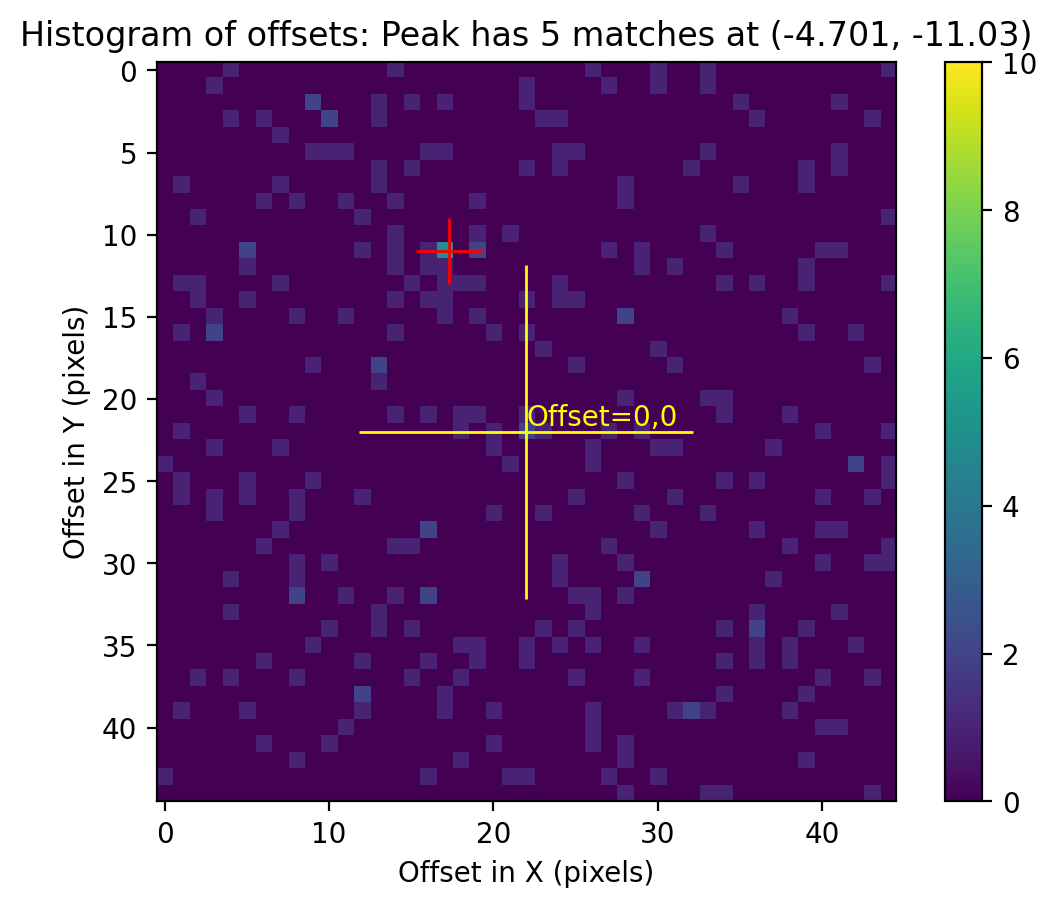

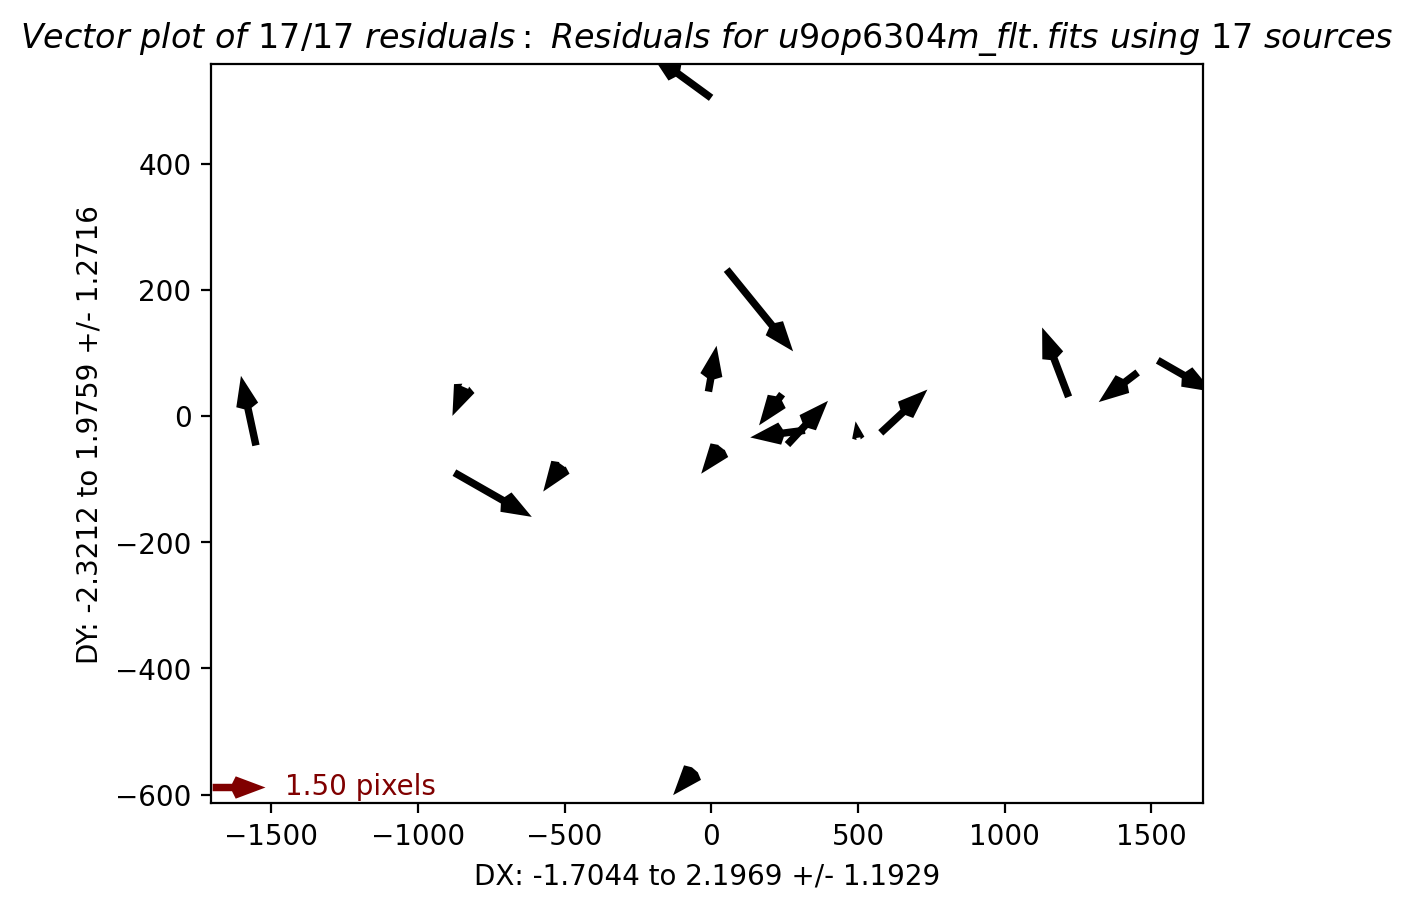

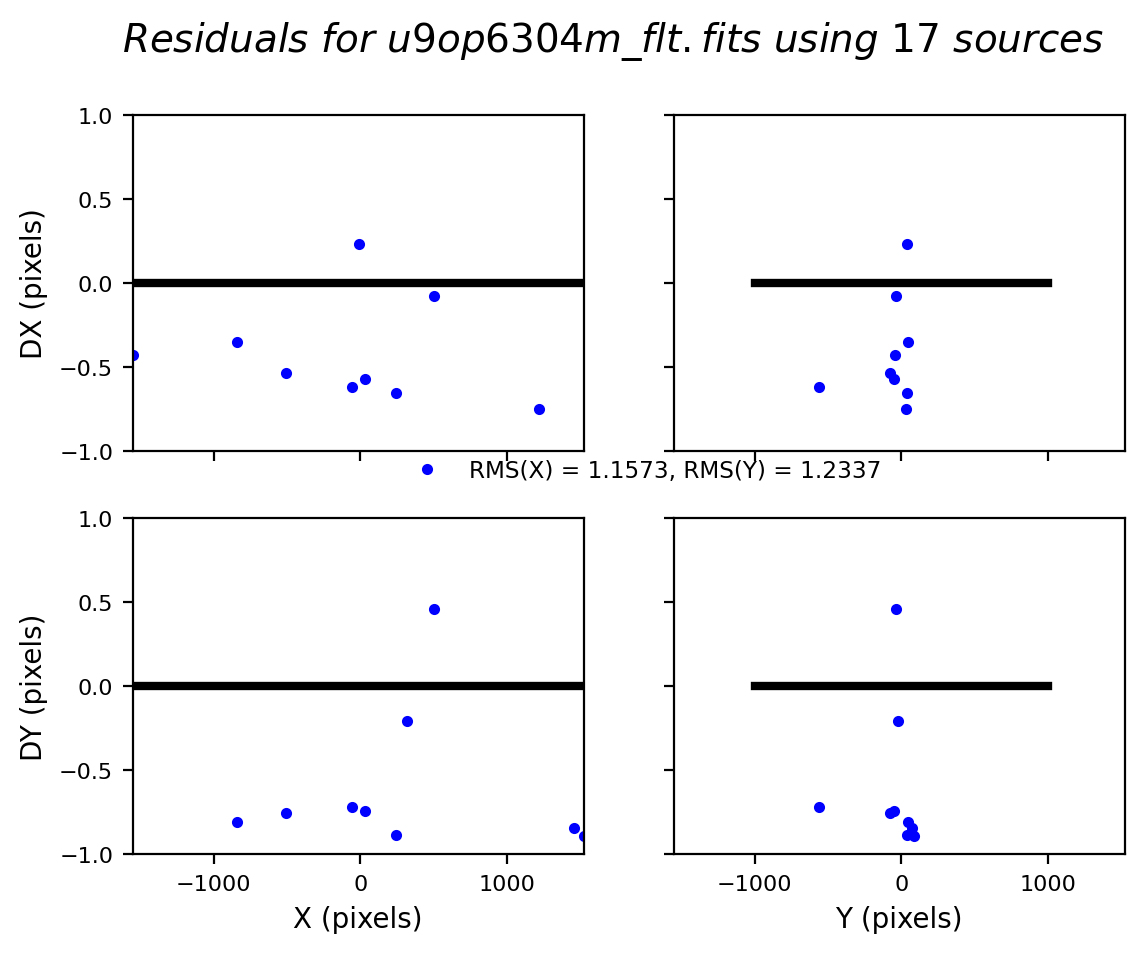

In [8]:
input_images = sorted(glob.glob('u*flt.fits'))

tweakreg.TweakReg(input_images, 
                  updatehdr=True, 
                  clean=True,
                  reusename=True, 
                  interactive=False,
                  conv_width=3.0, 
                  threshold=200.0,
                  ylimit=1,
                  shiftfile=True, 
                  outshifts='shift_flt.txt',
                  searchrad=1,
                  tolerance=3,
                  minobj=7)
clear_output()

In [9]:
input_images = sorted(glob.glob('u*c0m.fits'))

tweakreg.TweakReg(input_images, 
                  updatehdr=True, 
                  clean=True,
                  reusename=True, 
                  interactive=False,
                  conv_width=3.0, 
                  threshold=200.0,
                  ylimit=1,
                  shiftfile=True, 
                  outshifts='shift_c0m.txt',
                  searchrad=1,
                  tolerance=3,
                  minobj=7)

clear_output()
plt.close()

In [10]:
def mask_wf_chips(flt_files):
    """Copy flt files with WF chips (SCI 2,3,4) fully masked in DQ so AstroDrizzle ignores them."""
    masked_files = []
    for fname in flt_files:
        out_fname = 'pconly_' + os.path.basename(fname)
        with fits.open(fname) as hdul:
            new_hdul = hdul.copy()
            for chip in [2, 3, 4]:
                new_hdul['DQ', chip].data[:] = 4  # bad detector pixel — excluded by driz_sep_bits/final_bits
            new_hdul.writeto(out_fname, overwrite=True)
        masked_files.append(out_fname)
    return masked_files

flt_pc_files = mask_wf_chips(sorted(glob.glob('u*flt.fits')))

In [11]:
astrodrizzle.AstroDrizzle(flt_pc_files, 
                          output='wfpc2_flt', 
                          preserve=False, 
                          build=False, 
                          context=False, 
                          skysub=True, 
                          skymethod='localmin',
                          driz_sep_wcs=True, 
                          driz_sep_scale=0.0455, 
                          driz_sep_bits='8,1024', 
                          driz_sep_fillval=-1, 
                          median=False, 
                          blot=False,
                          driz_cr=False,
                          final_fillval=None, 
                          final_bits='8,1024', 
                          final_wcs=True, 
                          final_scale=0.0455)
clear_output()

In [ ]:
c0m_pc = [f for f in sorted(glob.glob('u*c0m.fits'))]


astrodrizzle.AstroDrizzle(c0m_pc, 
                          output='wfpc2_c0m', 
                          preserve=False, 
                          build=False, 
                          context=False, 
                          static=True, 
                          skysub=False, 
                          driz_sep_wcs=True, 
                          driz_sep_refimage=f'{dat}1m_single_sci.fits', 
                          driz_sep_bits='8,1024', 
                          driz_sep_fillval=-1, 
                          median=False, 
                          blot=False, 
                          driz_cr=False, 
                          final_fillval=None, 
                          final_bits='8,1024', 
                          final_wcs=True, 
                          final_scale=0.0455, 
                          final_refimage='wfpc2_flt_drw_sci.fits',
                          group=1)
clear_output()

In [ ]:
fits_files = glob.glob('*ask.fits')
for f in fits_files:
    base_name = os.path.basename(f)
    if os.path.isfile(base_name):
        os.remove(base_name)

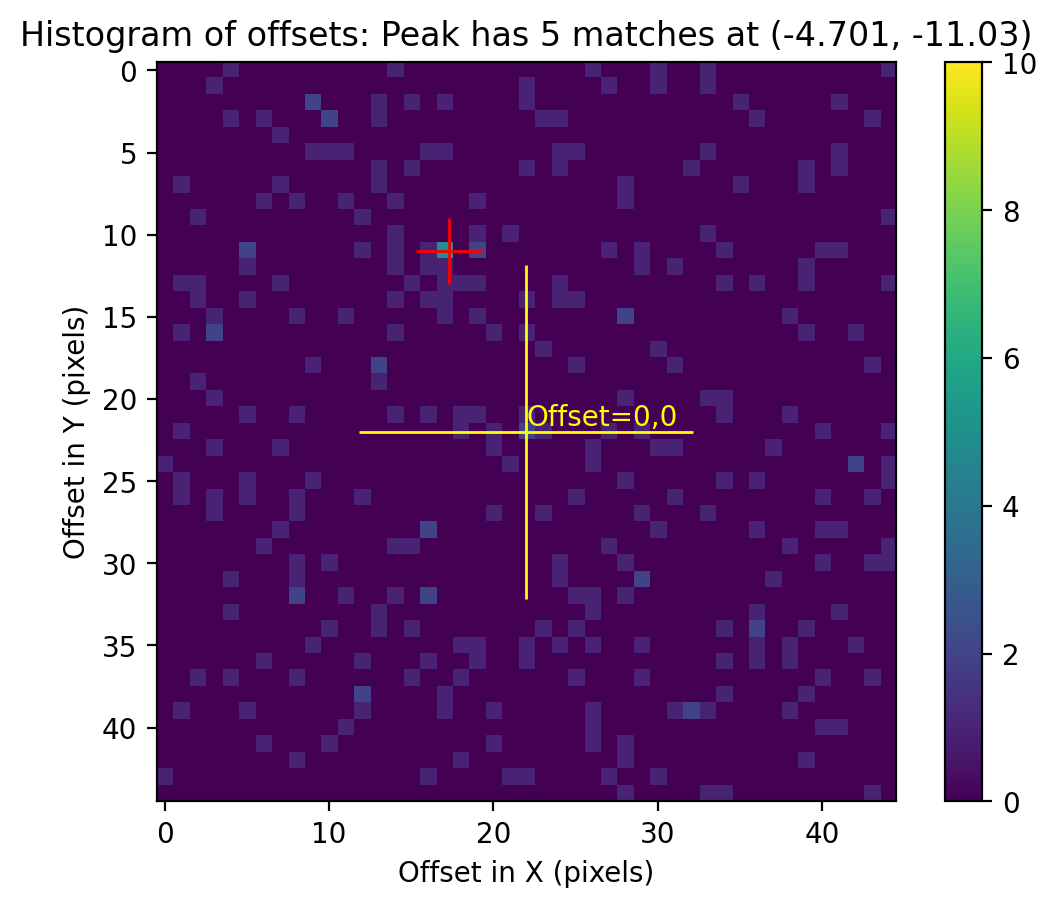

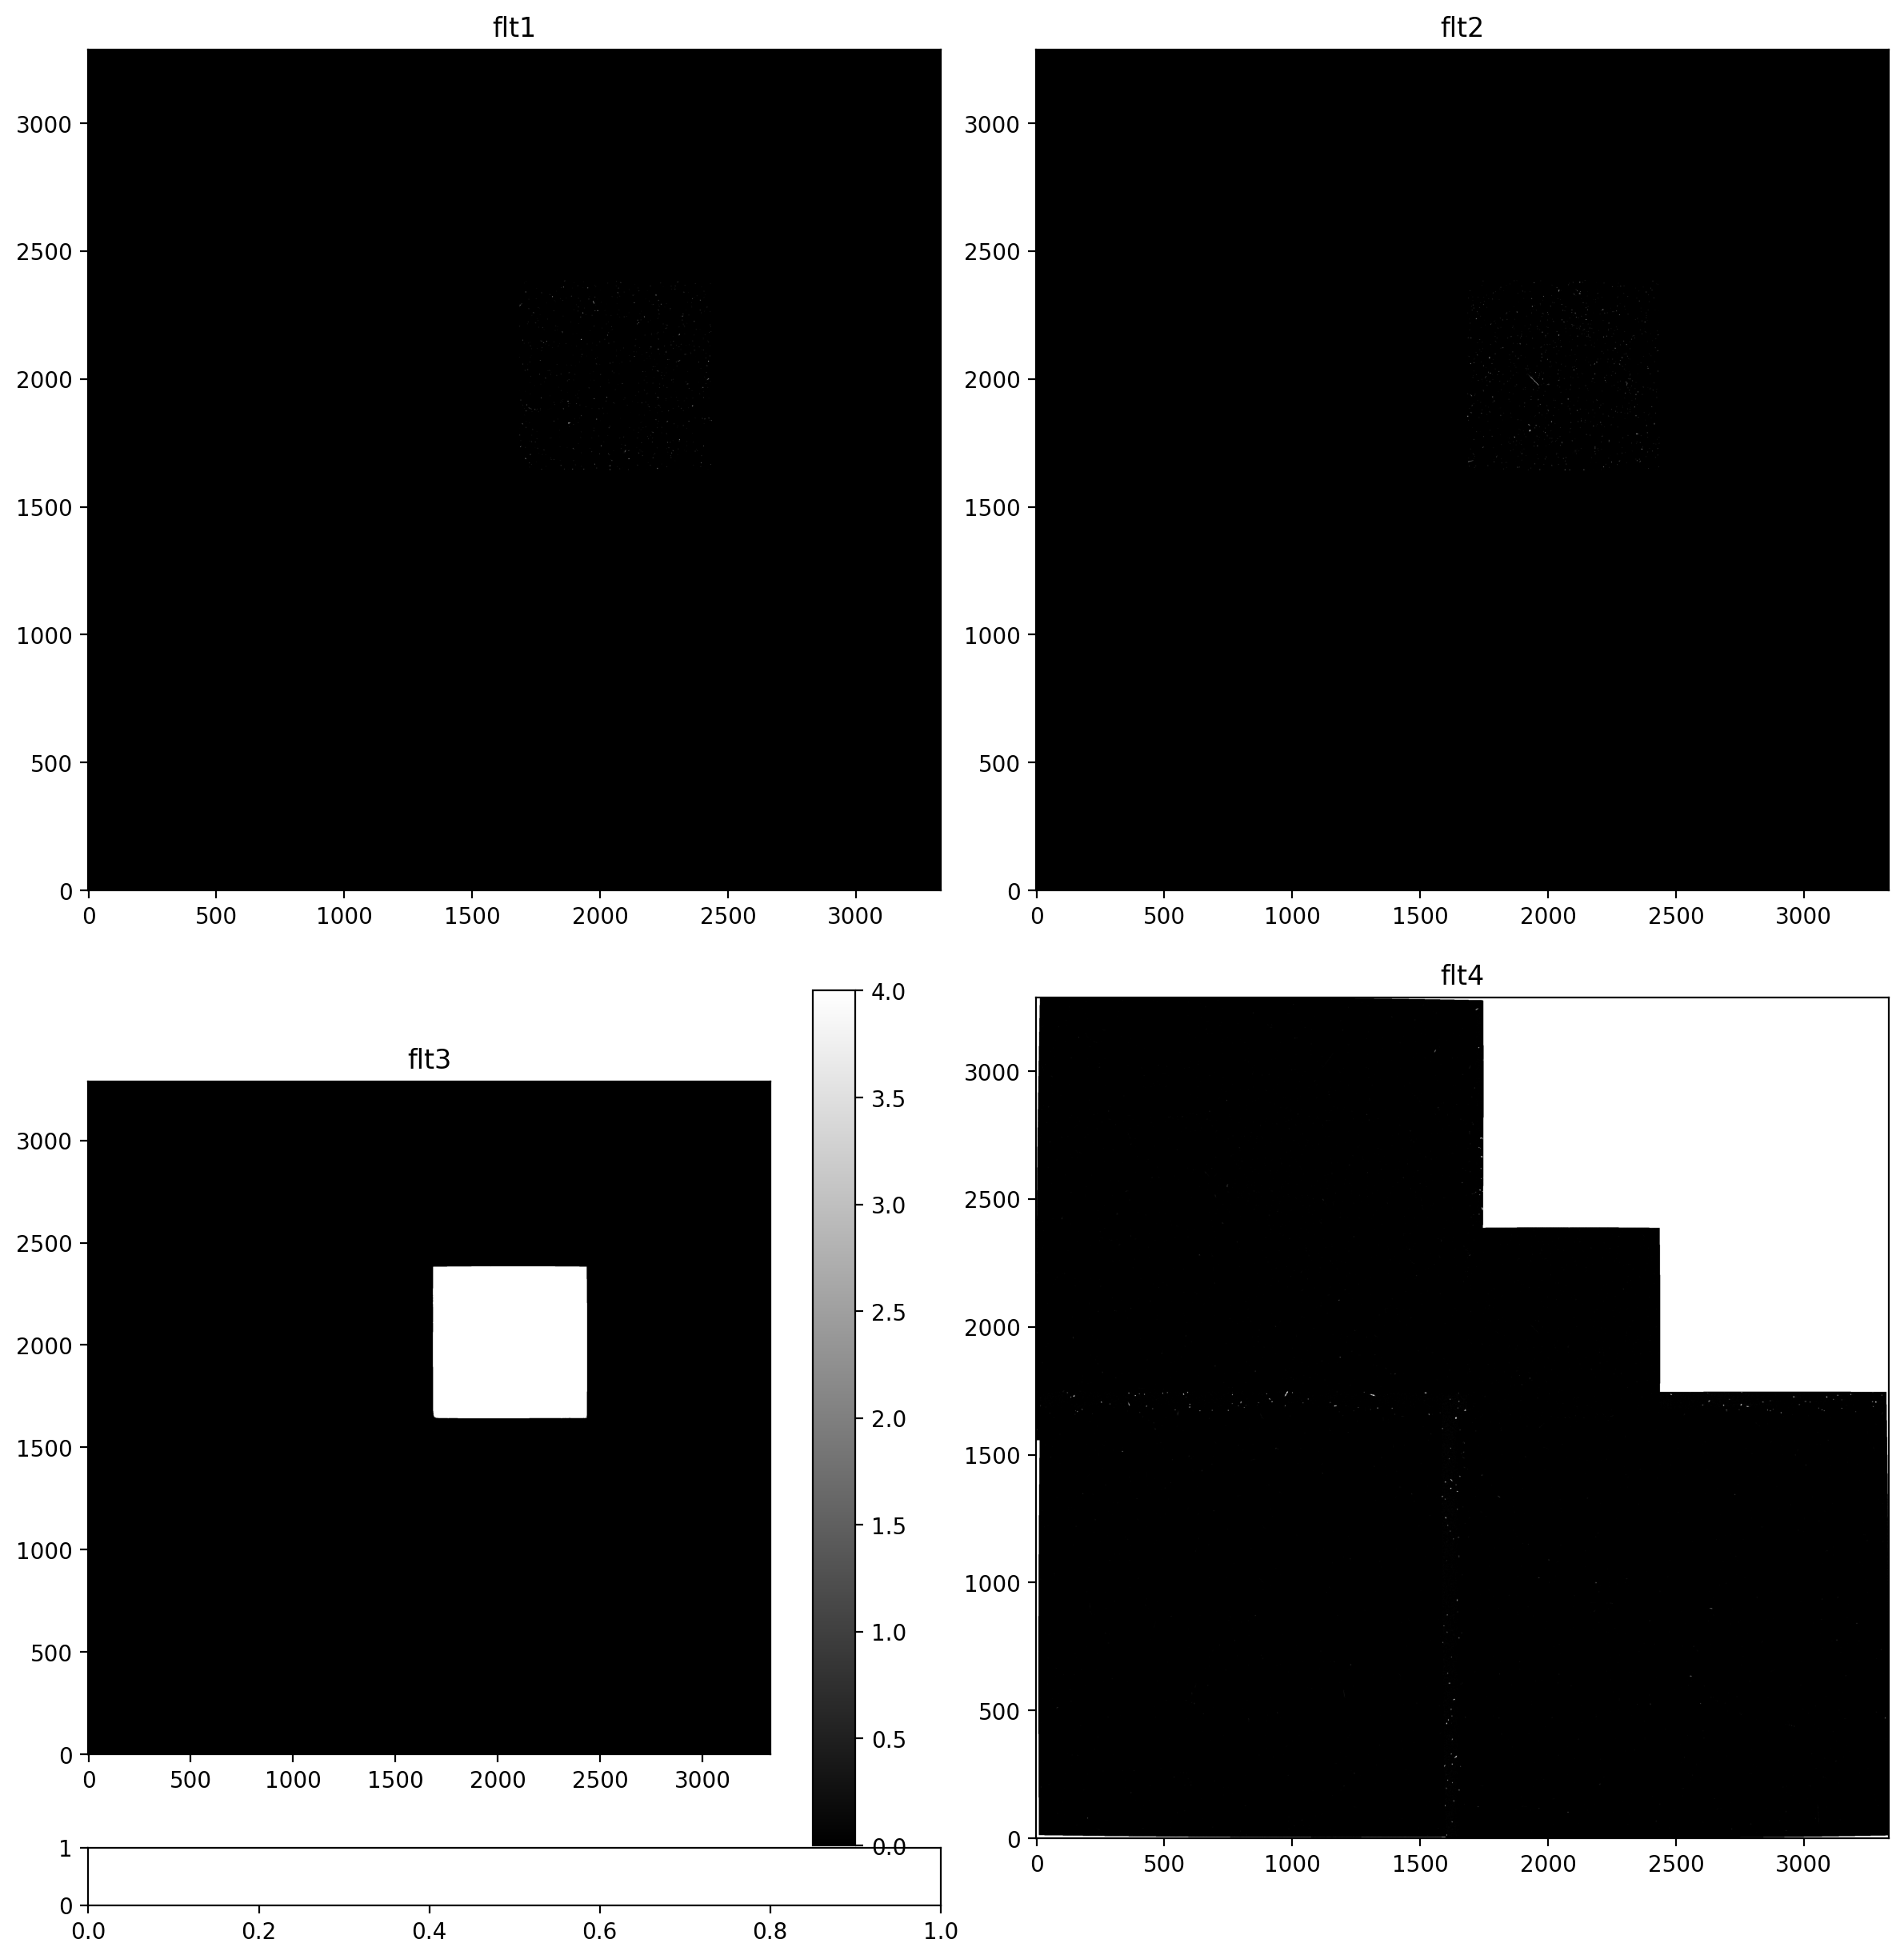

In [12]:
plt.close()
drz1_single = fits.getdata(f'pconly_{dat}1m_single_sci.fits')
drz2_single = fits.getdata(f'pconly_{dat}2m_single_sci.fits')
drz3_single = fits.getdata(f'wfpc2_flt_drw_wht.fits')
drz4_single = fits.getdata(f'wfpc2_flt_drw_sci.fits')

fig, (axs1, axs2) = plt.subplots(ncols=2, nrows=2, figsize=(12,12))
im1 = axs1[0].imshow(drz1_single, cmap='gray', vmin=0, vmax=4, origin='lower')
axs1[0].set_title('flt1')
im2 = axs1[1].imshow(drz2_single, cmap='gray', vmin=0, vmax=4, origin='lower')
axs1[1].set_title('flt2')
im3 = axs2[0].imshow(drz3_single, cmap='gray', vmin=0, vmax=4, origin='lower')
axs2[0].set_title('flt3')
im4 = axs2[1].imshow(drz4_single, cmap='gray', vmin=0, vmax=4, origin='lower')
axs2[1].set_title('flt4')

fig.tight_layout()
x1 = axs1[0].get_position().get_points().flatten()[0]
x2 = axs2[0].get_position().get_points().flatten()[2] - x1
ax_cbar = fig.add_axes([x1, 0, x2, 0.03])
#plt.colorbar(im1, cax=ax_cbar, orientation='horizontal')
plt.colorbar(im3)
plt.show()

In [ ]:
drz1_c0m_single = fits.getdata(f'{dat}1m_c0m_single_sci.fits')
drz2_c0m_single = fits.getdata(f'{dat}2m_c0m_single_sci.fits')

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 10))
im1 = ax1.imshow(drz1_single, cmap='gray', vmin=0, vmax=4, origin='lower')
ax1.set_title('Target on PC')
im2 = ax2.imshow(drz2_single, cmap='gray', vmin=0, vmax=4, origin='lower')
ax2.set_title('Target on WF1')

x1 = ax1.get_position().get_points().flatten()[0]
x2 = ax2.get_position().get_points().flatten()[2] - x1
ax_cbar = fig.add_axes([x1, 0, x2, 0.03])
plt.colorbar(im1, cax=ax_cbar, orientation='horizontal')
plt.show()

In [ ]:
ratio_flt_c0m = drz1_single/drz1_c0m_single
fig = plt.figure(figsize=(7, 7))
img_ratio = plt.imshow(ratio_flt_c0m, vmin=0.97, vmax=1.03, cmap='Greys_r', origin='lower')
plt.colorbar(img_ratio, orientation='vertical')
plt.show()